# Module 5: Business Forecasting with Prophet

## Data: website_traffic

##  1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install prophet -qq
from prophet import Prophet


c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load & Clean Data

In [99]:

path = "../data/website_traffic.csv"
df = pd.read_csv(path)

# Fix date formatting
df["Date"] = df["Date"].str.replace("/", "-")
df["Date"] = pd.to_datetime(df["Date"])

# Drop missing visits
df = df.dropna(subset=["Visits"])

# Sort chronologically
df = df.sort_values("Date")

# Rename for Prophet
df = df.rename(columns={"Date": "ds", "Visits": "y"})

#Remove duplicate dates by aggregating
df = df.groupby("ds")["y"].sum().reset_index()

print("Cleaned Data Shape:", df.shape)
print(df.dtypes)

Cleaned Data Shape: (232, 2)
ds    datetime64[ns]
y            float64
dtype: object


## 3. Fix Missing Days 

In [100]:
df = df.set_index("ds").asfreq("D")
df["y"] = df["y"].interpolate()   # Smooth missing days
df = df.reset_index()

## 4. Log Transform (Prevents Negative Predictions)

In [101]:
df["y_log"] = np.log(df["y"])

## 5. Visualize Raw Traffic

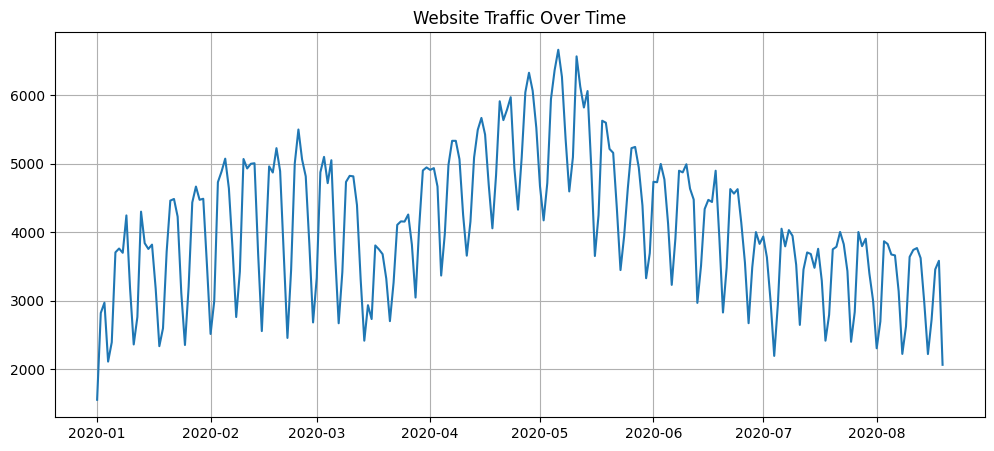

In [102]:
plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"])
plt.title("Website Traffic Over Time")
plt.grid(True)
plt.show()

## 6. Prophet Model 

In [103]:
# Create a NEW model before fitting log-transformed data
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

# Pass only the date and the logged target column
model.fit(df[['ds', 'y_log']].rename(columns={"y_log": "y"}))

## 7. Forecast Future

In [104]:

future = model.make_future_dataframe(periods=30, freq="D")
forecast = model.predict(future)

# Convert back from log scale
forecast["yhat_exp"] = np.exp(forecast["yhat"])
forecast["yhat_lower_exp"] = np.exp(forecast["yhat_lower"])
forecast["yhat_upper_exp"] = np.exp(forecast["yhat_upper"])

## 8.Plot Forecast

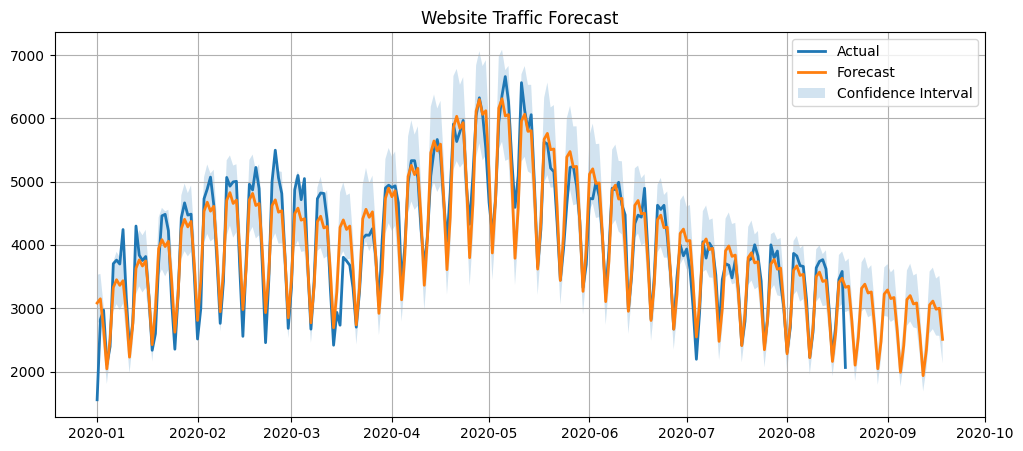

In [105]:
plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"], label="Actual", linewidth=2)
plt.plot(forecast["ds"], forecast["yhat_exp"], label="Forecast", linewidth=2)
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower_exp"],
    forecast["yhat_upper_exp"],
    alpha=0.2,
    label="Confidence Interval"
)
plt.title("Website Traffic Forecast")
plt.legend()
plt.grid(True)
plt.show()



## 9. Prophet Components

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


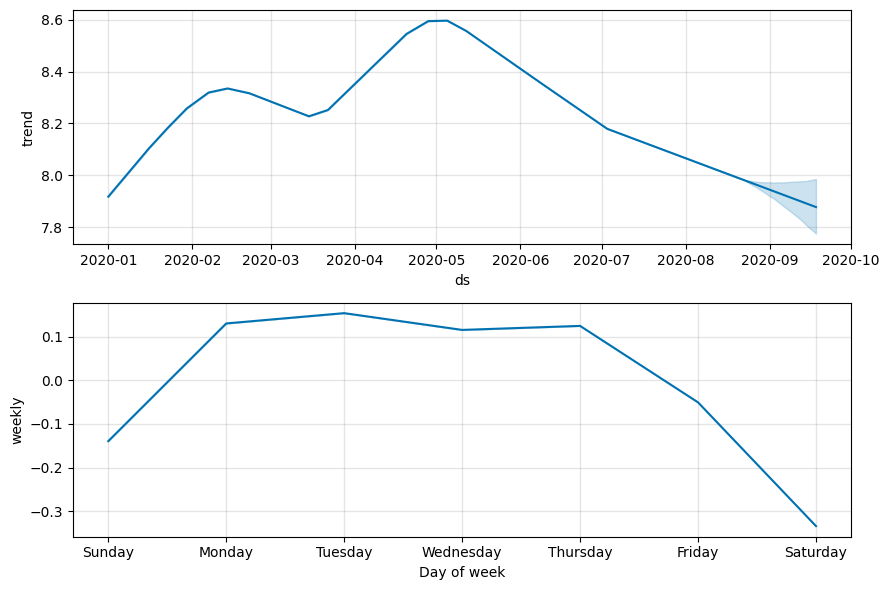

In [106]:
model.plot_components(forecast)
plt.show()

## DIAGNOSTICS SECTION

##### 1. Trend Stability

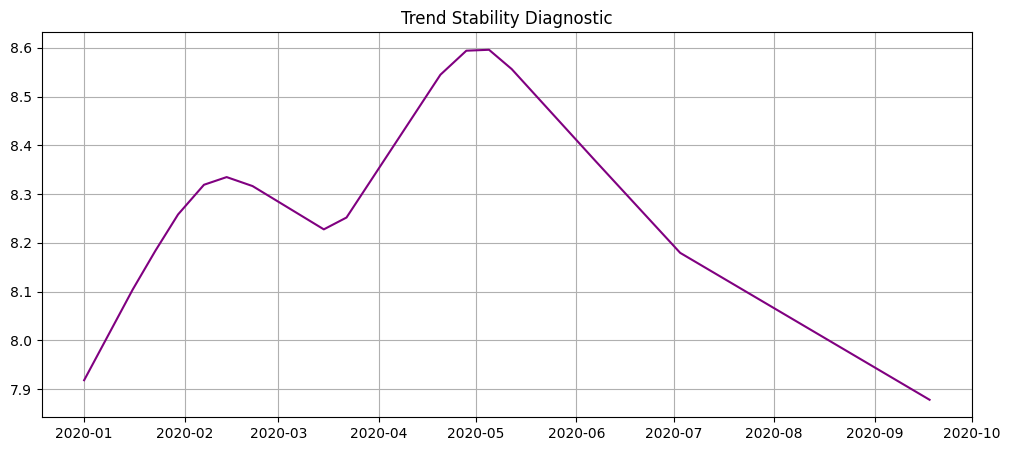

In [107]:
plt.figure(figsize=(12,5))
plt.plot(forecast["ds"], forecast["trend"], color="purple")
plt.title("Trend Stability Diagnostic")
plt.grid(True)
plt.show()


#### 2. Changepoint Diagnostics

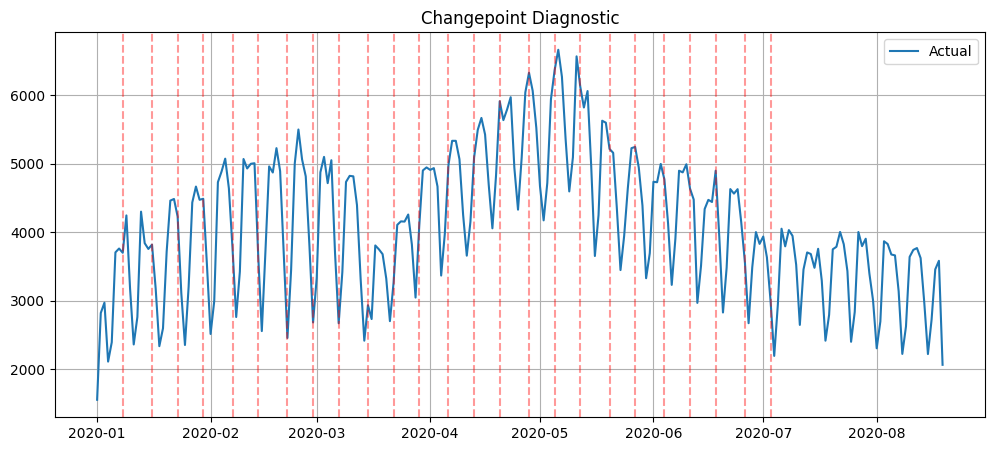

In [108]:
plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"], label="Actual")
for cp in model.changepoints:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.4)
plt.title("Changepoint Diagnostic")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Uncertainty Width

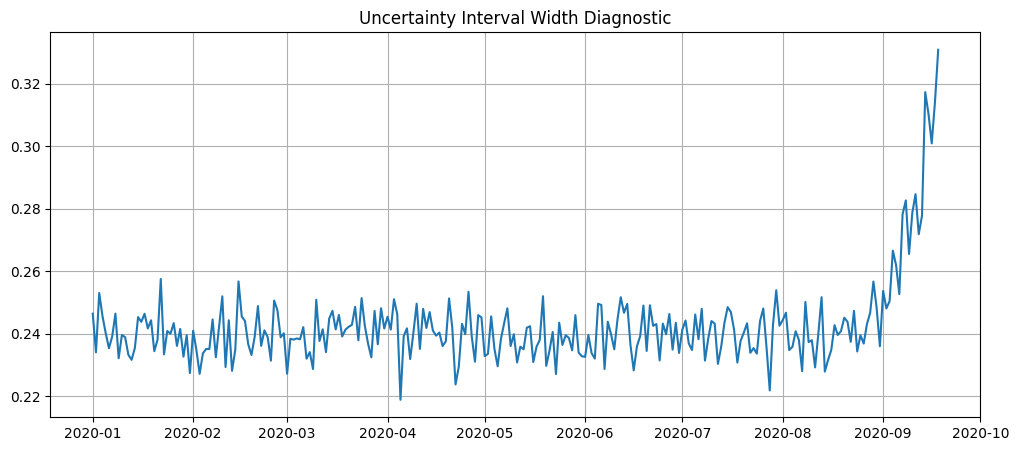

In [109]:
forecast["interval_width"] = forecast["yhat_upper"] - forecast["yhat_lower"]
plt.figure(figsize=(12,5))
plt.plot(forecast["ds"], forecast["interval_width"])
plt.title("Uncertainty Interval Width Diagnostic")
plt.grid(True)
plt.show()
